In [1]:
# PASO 1 (EDA): INSTALACIÓN, LIBRERÍAS Y CARGA DE TABLAS LIMPIAS DESDE DRIVE

!pip install -q pingouin lifelines ydata-profiling missingno

import requests, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns, plotly.express as px
import scipy.stats as stats
import statsmodels.api as sm, statsmodels.formula.api as smf
import pingouin as pg, missingno as msno
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from lifelines import KaplanMeierFitter, CoxPHFitter
from ydata_profiling import ProfileReport

from google.colab import drive
drive.mount('/content/drive')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
CREDITO = "Football data by 5DollarFootballAPI (5dollarfootballapi.com)"   # para pie de gráficas

CARPETA = "/content/drive/MyDrive/proyecto-futbol"
part = pd.read_csv(f"{CARPETA}/liga1_apertura2026_partidos.csv")
evs = pd.read_csv(f"{CARPETA}/liga1_apertura2026_eventos.csv")

for d in (part, evs):
    d["kickoff_lima"] = pd.to_datetime(d["kickoff_lima"], utc=True).dt.tz_convert("America/Lima")

print("Partidos:", part.shape, "| Eventos:", evs.shape)
print("Rango de fechas:", part["kickoff_lima"].min().date(), "->", part["kickoff_lima"].max().date())
print("\nBanderas de calidad (partidos OK):")
print(part[["stats_validas", "ht_valido", "ev_goles_ok", "ev_amarillas_ok"]].sum().to_string())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.5 MB/s eta 0:00:00


/tmp/ipykernel_2751/3401279241.py:14: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Mounted at /content/drive
Partidos: (153, 51) | Eventos: (3731, 14)
Rango de fechas: 2026-01-30 -> 2026-05-31

Banderas de calidad (partidos OK):
stats_validas      150
ht_valido          144
ev_goles_ok        152
ev_amarillas_ok    150


In [2]:
# PASO 2: TABLA DE EFICIENCIA POR EQUIPO (PRODUCCIÓN, CONVERSIÓN Y PUNTOS)

import os
CARPETA_G = f"{CARPETA}/graficas/eficiencia"
os.makedirs(CARPETA_G, exist_ok=True)

def guardar(fig, nombre):
    fig.text(0.99, 0.01, CREDITO, ha="right", va="bottom", fontsize=8, color="gray")
    fig.tight_layout(rect=[0, 0.03, 1, 1])
    fig.savefig(f"{CARPETA_G}/{nombre}.png", dpi=200, bbox_inches="tight")
    plt.show()

# 1) Formato largo: una fila por equipo y partido, con sus stats y las del rival
def lado(d, yo, el):
    return pd.DataFrame({
        "fixture_id": d["id"], "equipo": d[f"teams_{yo}_name"], "condicion": yo,
        "stats_validas": d["stats_validas"],
        "gf": d[f"goals_{yo}"], "gc": d[f"goals_{el}"], "pts": d[f"pts_{yo}"],
        "tiros_arco": d[f"shots_on_target_{yo}"], "tiros_fuera": d[f"shots_off_target_{yo}"],
        "ataques_pelig": d[f"dangerous_attacks_{yo}"], "posesion": d[f"possession_{yo}"],
        "tiros_arco_rival": d[f"shots_on_target_{el}"],
        "tiros_fuera_rival": d[f"shots_off_target_{el}"],
        "ataques_pelig_rival": d[f"dangerous_attacks_{el}"],
    })

eq = pd.concat([lado(part, "home", "away"), lado(part, "away", "home")], ignore_index=True)
eq["tiros"] = eq["tiros_arco"] + eq["tiros_fuera"]
eq["tiros_rival"] = eq["tiros_arco_rival"] + eq["tiros_fuera_rival"]

# 2) Controles
v = eq[eq["stats_validas"]]
print(f"Equipo-partidos totales: {len(eq)} | con stats válidas: {len(v)} (esperado 300)")
print(f"Casos con goles > tiros al arco (stats válidas): {(v['gf'] > v['tiros_arco']).sum()}")

# 3) Puntos y goles: 153 partidos
pts = eq.groupby("equipo").agg(PJ=("pts", "size"), Pts=("pts", "sum"), GF=("gf", "sum"), GC=("gc", "sum"))

# 4) Producción y conversión: 150 partidos con stats válidas
s = v.groupby("equipo").agg(PJ_stats=("gf", "size"), gf=("gf", "sum"), gc=("gc", "sum"),
                            tiros=("tiros", "sum"), tiros_arco=("tiros_arco", "sum"),
                            ataques_pelig=("ataques_pelig", "sum"), posesion=("posesion", "mean"),
                            tiros_rival=("tiros_rival", "sum"), tiros_arco_rival=("tiros_arco_rival", "sum"),
                            ataques_pelig_rival=("ataques_pelig_rival", "sum"))

ef = pd.DataFrame({
    "Pts": pts["Pts"],
    "PPP": pts["Pts"] / pts["PJ"],
    "GF": pts["GF"], "GC": pts["GC"],
    "PJ_stats": s["PJ_stats"],
    "Posesion_%": s["posesion"],
    "AtaqPelig_pp": s["ataques_pelig"] / s["PJ_stats"],
    "Tiros_pp": s["tiros"] / s["PJ_stats"],
    "TirosArco_pp": s["tiros_arco"] / s["PJ_stats"],
    "Precision_%": s["tiros_arco"] / s["tiros"] * 100,           # % de tiros que van al arco
    "Goles_x100_TirosArco": s["gf"] / s["tiros_arco"] * 100,     # conversión ofensiva
    "Goles_x100_AtaqPelig": s["gf"] / s["ataques_pelig"] * 100,
    "TirosArco_rival_pp": s["tiros_arco_rival"] / s["PJ_stats"],
    "GC_x100_TirosArco_rival": s["gc"] / s["tiros_arco_rival"] * 100,  # qué tanto le convierten
}).sort_values("PPP", ascending=False)

print("\nTABLA DE EFICIENCIA (ordenada por puntos por partido):")
print(ef.round(1).to_string())

Equipo-partidos totales: 306 | con stats válidas: 300 (esperado 300)
Casos con goles > tiros al arco (stats válidas): 0

TABLA DE EFICIENCIA (ordenada por puntos por partido):
                           Pts  PPP  GF  GC  PJ_stats  Posesion_%  AtaqPelig_pp  Tiros_pp  TirosArco_pp  Precision_%  Goles_x100_TirosArco  Goles_x100_AtaqPelig  TirosArco_rival_pp  GC_x100_TirosArco_rival
equipo                                                                                                                                                                                                       
Alianza Lima                40  2.4  30   8        16        55.8          47.1      14.2           5.6         39.0                  31.5                   3.7                 2.6                     16.7
CD Los Chankas              34  2.0  25  21        17        49.7          30.5      12.5           4.5         36.2                  32.5                   4.8                 4.3                     28.8


CORRELACIÓN DE SPEARMAN CON PUNTOS POR PARTIDO (n = 18 equipos)
                                                   métrica    rho  p_valor
                                         Tiros por partido  0.636    0.005
                                 Tiros al arco por partido  0.628    0.005
                       Tiros al arco recibidos por partido -0.584    0.011
                                              Posesión (%)  0.487    0.040
Conversión del rival (goles recibidos / 100 tiros al arco) -0.377    0.123
                          Goles por 100 ataques peligrosos  0.336    0.173
                            Ataques peligrosos por partido  0.272    0.274
           Conversión ofensiva (goles / 100 tiros al arco)  0.218    0.386
                               Precisión (% tiros al arco) -0.048    0.851


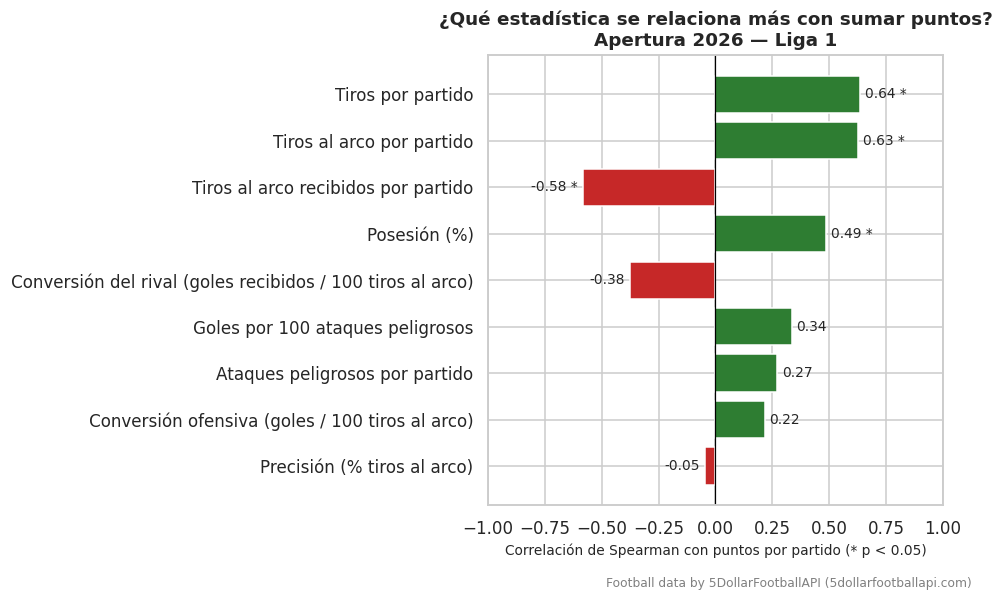

In [4]:
# PASO 3: CORRELACIÓN DE SPEARMAN — ¿QUÉ ESTADÍSTICA EXPLICA MEJOR LOS PUNTOS?

metricas = {
    "Posesion_%": "Posesión (%)",
    "AtaqPelig_pp": "Ataques peligrosos por partido",
    "Tiros_pp": "Tiros por partido",
    "TirosArco_pp": "Tiros al arco por partido",
    "Precision_%": "Precisión (% tiros al arco)",
    "Goles_x100_TirosArco": "Conversión ofensiva (goles / 100 tiros al arco)",
    "Goles_x100_AtaqPelig": "Goles por 100 ataques peligrosos",
    "TirosArco_rival_pp": "Tiros al arco recibidos por partido",
    "GC_x100_TirosArco_rival": "Conversión del rival (goles recibidos / 100 tiros al arco)",
}

filas = []
for col, nombre in metricas.items():
    rho, p = stats.spearmanr(ef[col], ef["PPP"])
    filas.append({"métrica": nombre, "rho": rho, "p_valor": p})

corr = pd.DataFrame(filas).sort_values("rho", key=abs, ascending=False).reset_index(drop=True)
print("CORRELACIÓN DE SPEARMAN CON PUNTOS POR PARTIDO (n = 18 equipos)")
print(corr.round(3).to_string(index=False))

# Gráfica: barras horizontales de rho
fig, ax = plt.subplots(figsize=(9, 5.5))
colores = ["#2E7D32" if r > 0 else "#C62828" for r in corr["rho"]]
ax.barh(corr["métrica"], corr["rho"], color=colores)
for i, (r, p) in enumerate(zip(corr["rho"], corr["p_valor"])):
    ax.text(r + (0.02 if r > 0 else -0.02), i, f"{r:.2f}{' *' if p < 0.05 else ''}",
            va="center", ha="left" if r > 0 else "right", fontsize=9)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlim(-1, 1)
ax.invert_yaxis()
ax.set_xlabel("Correlación de Spearman con puntos por partido (* p < 0.05)", fontsize=9)
ax.set_title("¿Qué estadística se relaciona más con sumar puntos?\nApertura 2026 — Liga 1", fontweight="bold")
guardar(fig, "01_correlaciones_con_puntos")

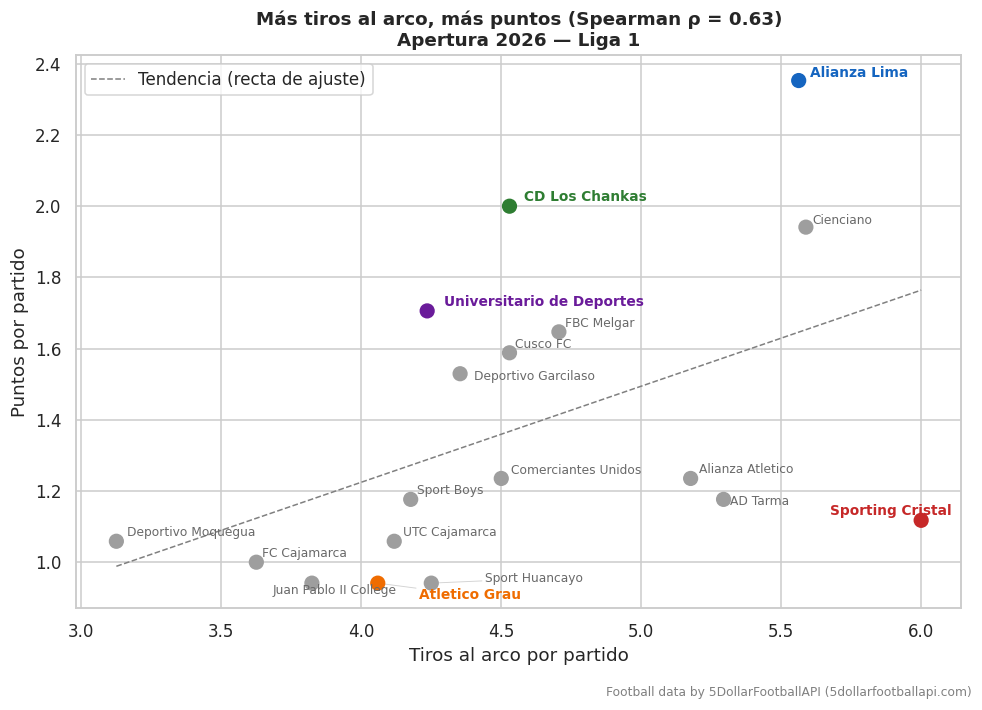

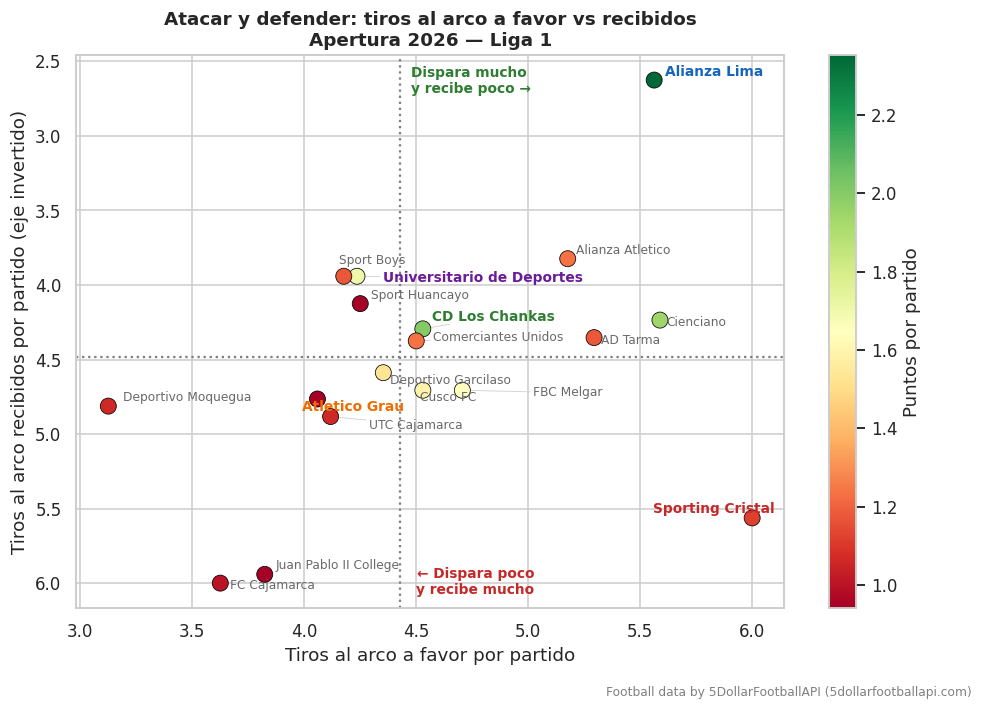

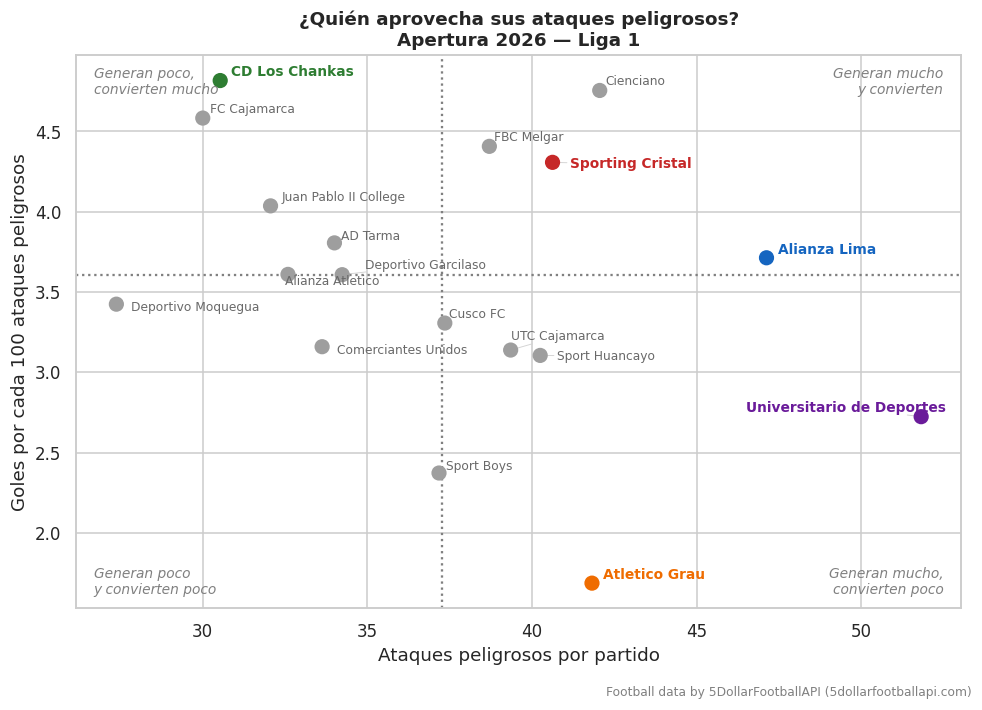

In [17]:
# PASO 4: GRÁFICAS DE DISPERSIÓN — VOLUMEN DE TIROS, DEFENSA Y EFICIENCIA

!pip install -q adjustText
from adjustText import adjust_text

DESTACADOS = {"Sporting Cristal": "#C62828", "Alianza Lima": "#1565C0",
              "Universitario de Deportes": "#6A1B9A", "CD Los Chankas": "#2E7D32",
              "Atletico Grau": "#EF6C00"}
colores = [DESTACADOS.get(e, "#9E9E9E") for e in ef.index]

def etiquetas(ax, x, y):
    textos = [ax.text(xi, yi, e, fontsize=9 if e in DESTACADOS else 8,
                      fontweight="bold" if e in DESTACADOS else "normal",
                      color=DESTACADOS.get(e, "dimgray"))
              for e, xi, yi in zip(ef.index, x, y)]
    adjust_text(textos, ax=ax, arrowprops=dict(arrowstyle="-", color="lightgray", lw=0.6))

# 1) Volumen: tiros al arco por partido vs puntos por partido
x, y = ef["TirosArco_pp"], ef["PPP"]
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.scatter(x, y, c=colores, s=80, zorder=3)
m, b0 = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, m * xs + b0, "--", color="gray", lw=1, label="Tendencia (recta de ajuste)")
etiquetas(ax, x, y)
ax.set_xlabel("Tiros al arco por partido")
ax.set_ylabel("Puntos por partido")
ax.set_title(f"Más tiros al arco, más puntos (Spearman ρ = {stats.spearmanr(x, y)[0]:.2f})\n"
             "Apertura 2026 — Liga 1", fontweight="bold")
ax.legend(loc="upper left")
guardar(fig, "02_tiros_al_arco_vs_puntos")

# 2) Atacar y defender: tiros al arco a favor vs recibidos (color = puntos por partido)
x, y = ef["TirosArco_pp"], ef["TirosArco_rival_pp"]
fig, ax = plt.subplots(figsize=(9, 6.5))
sc = ax.scatter(x, y, c=ef["PPP"], cmap="RdYlGn", s=110, edgecolor="black", linewidth=0.5, zorder=3)
plt.colorbar(sc, ax=ax, label="Puntos por partido")
ax.axvline(x.median(), color="gray", ls=":")
ax.axhline(y.median(), color="gray", ls=":")
ax.invert_yaxis()   # arriba = recibe menos tiros
etiquetas(ax, x, y)
ax.text(x.median() + 0.05, 0.98, "Dispara mucho\ny recibe poco →", transform=ax.get_xaxis_transform(),
        ha="left", va="top", fontsize=9, color="#2E7D32", fontweight="bold")
ax.text(x.median() + 0.60, 0.02, "← Dispara poco\ny recibe mucho", transform=ax.get_xaxis_transform(),
        ha="right", va="bottom", fontsize=9, color="#C62828", fontweight="bold")
ax.set_xlabel("Tiros al arco a favor por partido")
ax.set_ylabel("Tiros al arco recibidos por partido (eje invertido)")
ax.set_title("Atacar y defender: tiros al arco a favor vs recibidos\nApertura 2026 — Liga 1", fontweight="bold")
guardar(fig, "03_tiros_a_favor_vs_recibidos")

# 3) Eficiencia: ataques peligrosos por partido vs goles por cada 100 ataques peligrosos
x, y = ef["AtaqPelig_pp"], ef["Goles_x100_AtaqPelig"]
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.scatter(x, y, c=colores, s=80, zorder=3)
ax.axvline(x.median(), color="gray", ls=":")
ax.axhline(y.median(), color="gray", ls=":")
etiquetas(ax, x, y)
for tx, ty, txt, ha, va in [(0.98, 0.98, "Generan mucho\ny convierten", "right", "top"),
                            (0.98, 0.02, "Generan mucho,\nconvierten poco", "right", "bottom"),
                            (0.02, 0.98, "Generan poco,\nconvierten mucho", "left", "top"),
                            (0.02, 0.02, "Generan poco\ny convierten poco", "left", "bottom")]:
    ax.text(tx, ty, txt, transform=ax.transAxes, ha=ha, va=va, fontsize=9, color="gray", fontstyle="italic")
ax.set_xlabel("Ataques peligrosos por partido")
ax.set_ylabel("Goles por cada 100 ataques peligrosos")
ax.set_title("¿Quién aprovecha sus ataques peligrosos?\nApertura 2026 — Liga 1", fontweight="bold")
guardar(fig, "04_ataques_peligrosos_vs_eficiencia")